1 - Install Library

In [6]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install Sastrawi
!pip install wordcloud
!pip install scikit-learn
!pip install joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


2 - Import Library

In [7]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

3 - Load Dataset

In [8]:
df = pd.read_csv("hasil_scraping_OCBC.csv")

df.head()

,Username,Review,Rating,Tanggal
0,Pengguna Google,"sangat puas dengan pelayanan keluhan nya,uang ...",5,2026-07-11 08:14:27
1,Pengguna Google,saya ingin bertanya berapa hari kartu debit ny...,3,2026-07-10 06:58:34
2,Pengguna Google,kenapa mbanking saya tidak bisa melakukan tran...,4,2026-07-10 02:22:07
3,Pengguna Google,siap 👍,5,2026-07-09 01:39:14
4,Pengguna Google,Sistem pelayanan dan M-banking nya sangat kura...,1,2026-07-08 14:10:27


4 - Informasi Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12216 entries, 0 to 12215
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  12216 non-null  object
 1   Review    12216 non-null  object
 2   Rating    12216 non-null  int64 
 3   Tanggal   12216 non-null  object
dtypes: int64(1), object(3)
memory usage: 381.9+ KB


In [10]:
df.describe()

,Rating
count,12216.000000
mean,2.850606
std,1.804219
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,5.000000


In [11]:
df.shape

(12216, 4)

5 - Missing Value

In [12]:
df.isnull().sum()

,0
Username,0
Review,0
Rating,0
Tanggal,0


In [13]:
df = df.dropna()

6 - Duplicate

In [14]:
df = df.drop_duplicates(subset="Review")

In [15]:
df.shape

(12216, 4)

7 - Distribusi Rating

In [16]:
df["Rating"].value_counts()

,count
Rating,
1,5170
5,4420
2,1000
3,951
4,675


8 - Grafik Rating

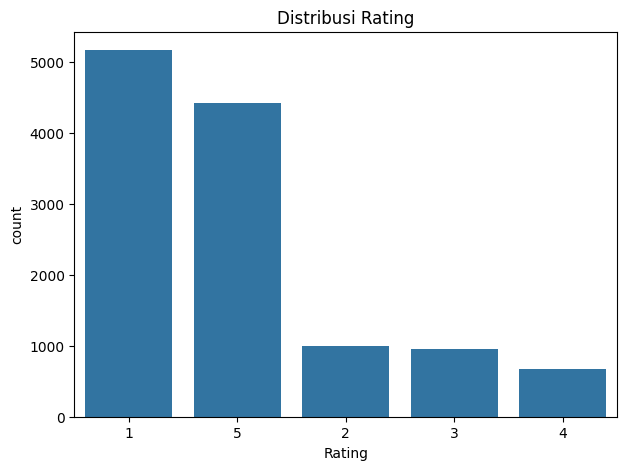

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Rating"],
    order=df["Rating"].value_counts().index
)

plt.title("Distribusi Rating")

plt.show()

9 - Cleaning Text

In [18]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    text = text.strip()

    return text

In [ ]:
df["clean_review"] = df["Review"].apply(clean_text)

df.head()

,Username,Review,Rating,Tanggal,clean_review
0,Pengguna Google,"sangat puas dengan pelayanan keluhan nya,uang ...",5,2026-07-11 08:14:27,sangat puas dengan pelayanan keluhan nyauang s...
1,Pengguna Google,saya ingin bertanya berapa hari kartu debit ny...,3,2026-07-10 06:58:34,saya ingin bertanya berapa hari kartu debit ny...
2,Pengguna Google,kenapa mbanking saya tidak bisa melakukan tran...,4,2026-07-10 02:22:07,kenapa mbanking saya tidak bisa melakukan tran...
3,Pengguna Google,siap 👍,5,2026-07-09 01:39:14,siap
4,Pengguna Google,Sistem pelayanan dan M-banking nya sangat kura...,1,2026-07-08 14:10:27,sistem pelayanan dan mbanking nya sangat kuran...


10 - Tokenizing

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df["tokens"] = df["clean_review"].apply(word_tokenize)

11 - Stopword

In [ ]:
stop_words = set(stopwords.words("indonesian"))

df["tokens"] = df["tokens"].apply(
    lambda x: [word for word in x if word not in stop_words]
)

12 - Stemming

In [ ]:
factory = StemmerFactory()

stemmer = factory.create_stemmer()

In [ ]:
df["stemmed"] = df["tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [ ]:
df["processed_review"] = df["stemmed"].apply(
    lambda x: " ".join(x)
)

df.head()

,Username,Review,Rating,Tanggal,clean_review,tokens,stemmed,processed_review
0,Pengguna Google,"sangat puas dengan pelayanan keluhan nya,uang ...",5,2026-07-11 08:14:27,sangat puas dengan pelayanan keluhan nyauang s...,"[puas, pelayanan, keluhan, nyauang]","[puas, layan, keluh, nyauang]",puas layan keluh nyauang
1,Pengguna Google,saya ingin bertanya berapa hari kartu debit ny...,3,2026-07-10 06:58:34,saya ingin bertanya berapa hari kartu debit ny...,"[kartu, debit, nya, kirim, alamat, tercantum]","[kartu, debit, nya, kirim, alamat, cantum]",kartu debit nya kirim alamat cantum
2,Pengguna Google,kenapa mbanking saya tidak bisa melakukan tran...,4,2026-07-10 02:22:07,kenapa mbanking saya tidak bisa melakukan tran...,"[mbanking, transaksi, loading, sinyal, bagus]","[mbanking, transaksi, loading, sinyal, bagus]",mbanking transaksi loading sinyal bagus
3,Pengguna Google,siap 👍,5,2026-07-09 01:39:14,siap,[],[],
4,Pengguna Google,Sistem pelayanan dan M-banking nya sangat kura...,1,2026-07-08 14:10:27,sistem pelayanan dan mbanking nya sangat kuran...,"[sistem, pelayanan, mbanking, nya, kenyamanan,...","[sistem, layan, mbanking, nya, nyaman, mudah]",sistem layan mbanking nya nyaman mudah


13 - Label Sentimen

In [ ]:
def label_sentiment(score):

    if score >= 4:
        return "Positif"

    elif score == 3:
        return "Netral"

    else:
        return "Negatif"

In [ ]:
df["Sentiment"] = df["Rating"].apply(label_sentiment)

In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negatif,6170
Positif,5095
Netral,951


14 - Pie Chart

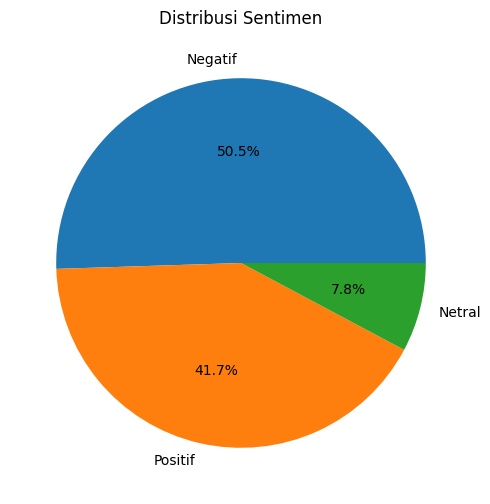

In [ ]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Distribusi Sentimen")

plt.show()

15 - WordCloud Positif

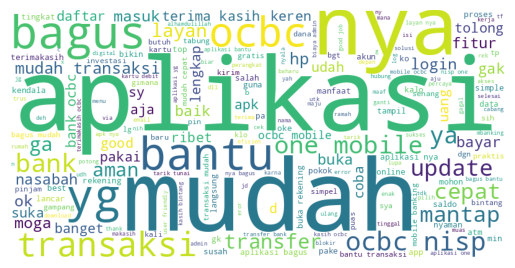

In [ ]:
positive = " ".join(
    df[df["Sentiment"]=="Positif"]["processed_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

16 - WordCloud Negatif

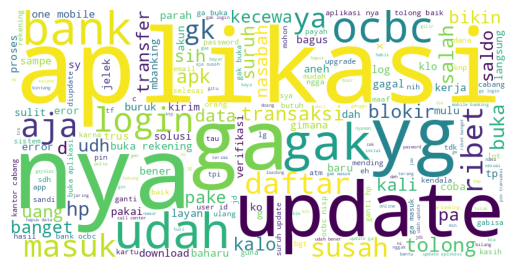

In [ ]:
negative = " ".join(
    df[df["Sentiment"]=="Negatif"]["processed_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

17 - TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["processed_review"])

y = df["Sentiment"]

18 - Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

19 - Training SVM

In [ ]:
svm = SVC(kernel="linear")

svm.fit(X_train, y_train)

SVC(kernel='linear')

20 - Prediksi

In [ ]:
y_pred = svm.predict(X_test)

21 - Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7737315875613748


22 - Precision Recall F1

In [ ]:
print("Precision :", precision_score(y_test, y_pred, average="weighted"))

print("Recall :", recall_score(y_test, y_pred, average="weighted"))

print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Precision : 0.7925379879761212
Recall : 0.7737315875613748
F1 Score : 0.7425867293916032


23 - Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       0.76      0.88      0.81      1235
      Netral       1.00      0.01      0.01       190
     Positif       0.80      0.79      0.79      1019

    accuracy                           0.77      2444
   macro avg       0.85      0.56      0.54      2444
weighted avg       0.79      0.77      0.74      2444



24 - Confusion Matrix

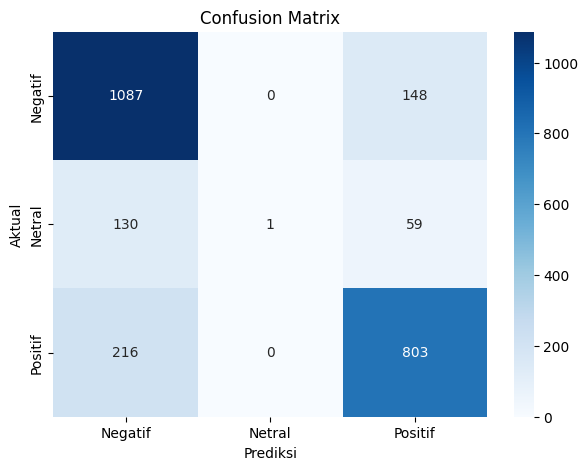

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm.classes_,
    yticklabels=svm.classes_
)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

25 - Simpan Model

In [ ]:
joblib.dump(svm, "svm_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

26 - Simpan Dataset Hasil Preprocessing

In [ ]:
df.to_csv(
    "dataset_preprocessing_OCBC.csv",
    index=False,
    encoding="utf-8-sig"
)